In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

project_path = "./examples/elastic/Iso-elastic-Marmousi2-shotTop-recTop/data"

init_vp=np.load(os.path.join(project_path ,"model/init_model.npz"))["vp"]
init_vs=np.load(os.path.join(project_path ,"model/init_model.npz"))["vs"]
init_rho=np.load(os.path.join(project_path,"model/init_model.npz"))["rho"]
true_vp=np.load(os.path.join(project_path ,"model/true_model.npz"))["vp"]
true_vs=np.load(os.path.join(project_path ,"model/true_model.npz"))["vs"]
true_rho=np.load(os.path.join(project_path,"model/true_model.npz"))["rho"]

def load_data(regular):
    iter_vp   = np.load(os.path.join(project_path,f"inversion_{regular}/iter_vp.npz"))["data"][:]
    iter_vs   = np.load(os.path.join(project_path,f"inversion_{regular}/iter_vs.npz"))["data"][:]
    iter_rho  = np.load(os.path.join(project_path,f"inversion_{regular}/iter_rho.npz"))["data"][:]
    iter_loss = np.load(os.path.join(project_path,f"inversion_{regular}/iter_loss.npz"))["data"][:]
    return iter_loss,iter_vp,iter_vs,iter_rho

iter_loss_tv2,iter_vp_tv2,iter_vs_tv2,iter_rho_tv2 = load_data("tv2")

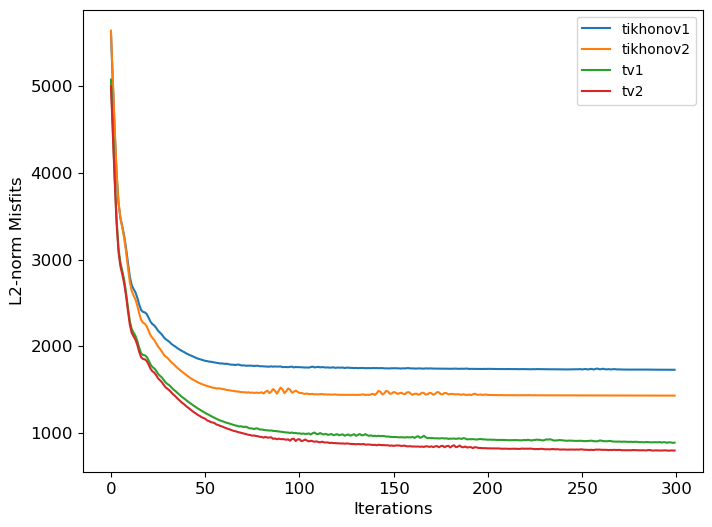

In [ ]:
# plot the misfit
plt.figure(figsize=(8,6))
plt.plot(iter_loss_tv2,label="tv2")
plt.legend()
plt.xlabel("Iterations", fontsize=12)
plt.ylabel("L2-norm Misfits", fontsize=12)
plt.tick_params(labelsize=12)
plt.show()

In [3]:
from ADFWI.utils.assessment_metric import *

In [5]:
ox,oz  = 0,0
nz,nx  = 78,200
dx,dz  = 45, 45
nt,dt  = 2500, 0.003
nabc   = 50
f0     = 3
free_surface = True

src_z = np.array([2   for i in range(2,nx-2,5)])*dz/1000 
src_x = np.array([i   for i in range(2,nx-2,5)])*dx/1000
rcv_z = np.array([2   for i in range(0,nx,1)])*dz/1000
rcv_x = np.array([j   for j in range(0,nx,1)])*dx/1000


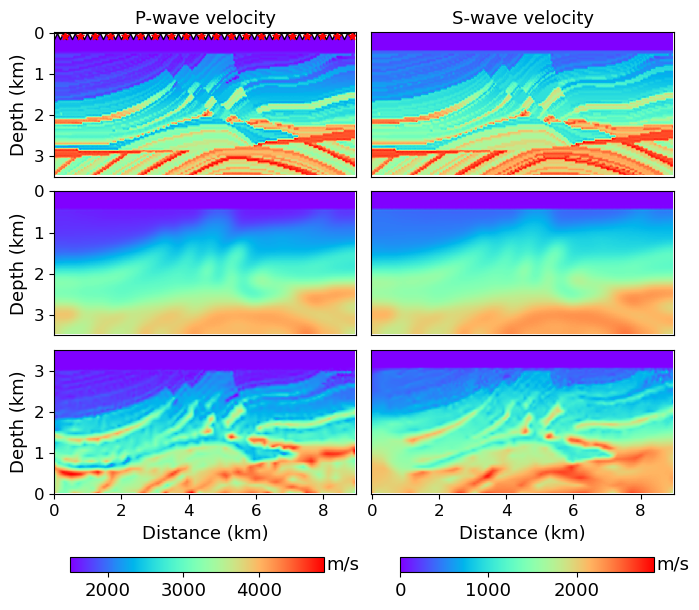

In [ ]:
from mpl_toolkits import axes_grid1
fig,axs = plt.subplots(3,2,figsize=(8,6))
# cmap="bwr"
cmap = "rainbow"
z = np.arange(0,nz*dz/1000,dz/1000)
x = np.arange(0,nx*dx/1000,dx/1000)
x_mesh, z_mesh = np.meshgrid(x, z)
x = np.arange(nx*3)*dx/3/1000
z = np.arange(nz*3)*dz/3/1000
x_mesh_new,z_mesh_new = np.meshgrid(x,z)
from scipy.interpolate import griddata
true_vp_new  = griddata((x_mesh.flatten(), z_mesh.flatten()), true_vp.flatten(), (x_mesh_new, z_mesh_new), method='cubic')
true_vs_new  = griddata((x_mesh.flatten(), z_mesh.flatten()), true_vs.flatten(), (x_mesh_new, z_mesh_new), method='cubic')
init_vp_new  = griddata((x_mesh.flatten(), z_mesh.flatten()), init_vp.flatten(), (x_mesh_new, z_mesh_new), method='cubic')
init_vs_new  = griddata((x_mesh.flatten(), z_mesh.flatten()), init_vs.flatten(), (x_mesh_new, z_mesh_new), method='cubic')
inv_vp_new   = griddata((x_mesh.flatten(), z_mesh.flatten()), iter_vp_tv2[-1].flatten(), (x_mesh_new, z_mesh_new), method='cubic')
inv_vs_new   = griddata((x_mesh.flatten(), z_mesh.flatten()), iter_vs_tv2[-1].flatten(), (x_mesh_new, z_mesh_new), method='cubic')

vpmin = true_vp.min()
vpmax = true_vp.max()
vsmin = true_vs.min()
vsmax = true_vs.max()

axs[0][0].pcolormesh(x_mesh_new,z_mesh_new,true_vp_new             ,cmap=cmap,vmin=vpmin,vmax=vpmax,shading="nearest")
axs[0][1].pcolormesh(x_mesh_new,z_mesh_new,true_vs_new             ,cmap=cmap,vmin=vsmin,vmax=vsmax,shading="nearest")
axs[1][0].pcolormesh(x_mesh_new,z_mesh_new,init_vp_new             ,cmap=cmap,vmin=vpmin,vmax=vpmax,shading="nearest")
axs[1][1].pcolormesh(x_mesh_new,z_mesh_new,init_vs_new             ,cmap=cmap,vmin=vsmin,vmax=vsmax,shading="nearest")
pcm1 = axs[2][0].pcolormesh(x_mesh_new,z_mesh_new,inv_vp_new[::-1] ,cmap=cmap,vmin=vpmin,vmax=vpmax,shading="nearest")
pcm2 = axs[2][1].pcolormesh(x_mesh_new,z_mesh_new,inv_vs_new[::-1] ,cmap=cmap,vmin=vsmin,vmax=vsmax,shading="nearest")

axs[0][0].scatter(rcv_x[::4],rcv_z[::4],facecolor="w",edgecolor='k',marker="v",s=20)
axs[0][0].scatter(src_x[1::2],src_z[1::2],c="r",marker="*",s=30)

axs[0][0].invert_yaxis()
axs[0][1].invert_yaxis()
axs[1][0].invert_yaxis()
axs[1][1].invert_yaxis()

axs[0][0].set_xticks([])
axs[0][1].set_xticks([])
axs[0][1].set_yticks([])
axs[1][0].set_xticks([])
axs[1][1].set_xticks([])
axs[1][1].set_yticks([])
axs[2][1].set_yticks([])

axs[0][0].set_ylabel("Depth (km)",fontsize=13)
axs[1][0].set_ylabel("Depth (km)",fontsize=13)
axs[2][0].set_ylabel("Depth (km)",fontsize=13)

axs[2][0].set_xlabel("Distance (km)",fontsize=13)
axs[2][1].set_xlabel("Distance (km)",fontsize=13)

axs[0][0].set_title(r"P-wave velocity",fontsize=13)
axs[0][1].set_title(r"S-wave velocity",fontsize=13)

for i in range(3):
    for j in range(2):
        axs[i][j].tick_params(labelsize=12)

cbar_pad_fraction   = 0.13
cbar_height         = 0.025
cax1 = fig.add_axes([axs[2][0].get_position().x0+0.02,axs[2][0].get_position().y0-cbar_pad_fraction,
                     axs[2][0].get_position().width*0.9,cbar_height])
cbar1 = plt.colorbar(pcm1,cax=cax1,orientation='horizontal')
cbar1.ax.tick_params(labelsize=13)
cbar1.ax.text(1.01, 0.5, "m/s", va='center', ha='left', fontsize=13, transform=cbar1.ax.transAxes)


cax2 = fig.add_axes([axs[2][1].get_position().x0+0.01,axs[2][1].get_position().y0-cbar_pad_fraction,
                     axs[2][1].get_position().width*0.9,cbar_height])
cbar2 = plt.colorbar(pcm2,cax=cax2,orientation='horizontal')
cbar2.ax.tick_params(labelsize=13)
cbar2.ax.text(1.01, 0.5, "m/s", va='center', ha='left', fontsize=13, transform=cbar2.ax.transAxes)

plt.subplots_adjust(hspace=0.1,wspace=0.05)

# plt.savefig(os.path.join(project_path,"Figure4_IsotropicElastic_Model_Test.png"),bbox_inches="tight",dpi=300)
plt.show()